In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
%matplotlib inline

c:\Users\yug\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
from keras.datasets import mnist

(xTrain,yTrain), (xTest,yTest) = mnist.load_data() #3 60k train, 10k test

3


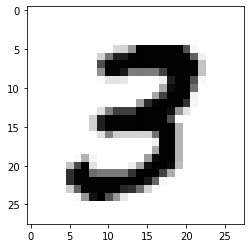

In [3]:
someNum=xTrain[7]
#np.reshape(someNum,(28,28)) No need to reshape as we already have a (28,28) dataset.
plt.imshow(someNum,cmap="binary")
print(yTrain[7])

In [4]:
from sklearn.preprocessing import StandardScaler

yTrain_5 = (yTrain == 5)
yTest_5 = (yTest==5)

xTrainRe = np.reshape(xTrain,(len(xTrain),784))
xTestRe = np.reshape(xTest,(len(xTest),784))

scaler = StandardScaler()
xTrainRe = scaler.fit_transform(xTrainRe.astype(np.float64))
xTestRe = scaler.fit_transform(xTestRe.astype(np.float64))

In [5]:
from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier()
sgd.fit(xTrainRe,yTrain_5)

SGDClassifier()

In [6]:
print(sgd.predict([xTestRe[0]]),yTest[0])

[False] 7


In [7]:
from sklearn.model_selection import cross_val_score

# CrossVal = cross_val_score(sgd,xTrainRe,yTrain_5,cv=3)
# CrossVal

IMPLEMENTING CROSSVAL FROM SCRATCH

In [8]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

def crossval(nFolds,nSplits,state,X,y,classifier):
    cloneCLF = clone(classifier)
    splits = StratifiedKFold(n_splits=nSplits, random_state=state, shuffle=True)
    
    for trainIndex, testIndex in splits.split(X,y):
        xTest,yTest = X[testIndex], y[testIndex]
        xTrain,yTrain = X[trainIndex], y[trainIndex]

    for i in range(nFolds):
        cloneCLF.fit(xTrain,yTrain)
        yPreds = cloneCLF.predict(xTest)
        nCorrect = sum(yPreds == yTest)
        print("Accuracy= ", nCorrect/len(yTest))

crossval(3,3,42,xTestRe,yTest_5,SGDClassifier()) # test set used just to speed up process

Accuracy=  0.9621962196219622
Accuracy=  0.960996099609961
Accuracy=  0.9603960396039604


<h1>CONFUSION MATRIX</h1>

The idea is to count the no. of times our classifier confused image of 3 with 5, 4 with 5, 6 with 5... and so on.

Each row is the actual class which each column is the predicted class.
first row is non-5 images, second is 5-images
first coln is non-5 images, second coln is 5-images
(False,True)
(False,
 True)
aise yaad kar


(0,0) pe negatives hai(true -ve's)
(1,1) pe +ve's(true +ve's)
(0,1) pe false +ve's(were classified as 5 even though they aren't 5)
(1,0) pe false -ve's(classified as non-5 even though they were 5)


<h1>PRECISION & RECALL</h1>
More concise than confusion matrix, but gives less information.

Precision = TP/(TP+FP)
Recall or Sensitivity or TP Rate(TPR) = TP/(TP+FN)

Precision is what proportion of predicted +ve mails are truly +ve. We want a spam classifier to be precise to lessen the false positives.
Recall is what proportion of truly +ve people are correctly classified. We want cancer detector to give false +ves, not false -ves. 

P and R can be combined in the form of something called the F1 score. Use when we don't know whether P or R is better for classifier.
F1 Score = HM of P,R
F1 score will be high only of 1/P, 1/R is low i.e P,R is high

F1 score favors classifiers with similar P,R. This is not always needed. Eg-
1) A classifier classifying videos safe for kids will want high precision but low recall as it's fine it many safe videos are removed; but unsafe videos must not pass.
2) A classifier for shoplifters may have low precision but will need high recall as it's good to be safe and check more people than to suffer a loss by not checking enough people at all.

**P Prop. to 1/R** this is precision recall tradeoff.

<h1>MULTICLASS CLASSIFICATION</h1> 
They are of two types. We will explain by taking example of MNIST dataset.
1) OvR(One Versus All)- Here, 10 classifier are trained to be 0-detector,1-detector, 2-detector,.... 9-detector. Now, an input is put into all 10 classifiers and the one with highest score is given as output.
2)OvO(One Versus One)- We make pairs of classifiers for every 2 digits-- so No. of classifiers is 10C2. An advantage of this is that each classifier is trained only on the 2 images it detects. i.e 1&2, 3&5, etc. OvO is preferred if the classifier being used scales shittily with the size of dataset.eg- SVM

For most binary classifiers, however, OvR is preferred.

In [9]:
from sklearn.svm import SVC

svc = SVC()
svc.fit(xTestRe,yTest)

SVC()

In [10]:
yPred = svc.predict(xTestRe)

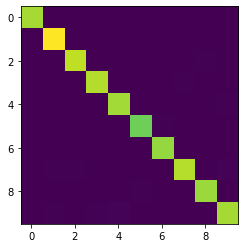

In [48]:
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(yTest, yPred)
plt.imshow(matrix)

The above heatmap is biased since for more abundant numbers,error will also be more abundant. We want to distinguish abundance and actual error rates. For this, divide each row by no. of images of that class. eg- no. in row 0 / no. of 0
We use rows since rows are true values.

In [49]:
rowSum = matrix.sum(axis=1, keepdims=True)
normMatrix = matrix/rowSum

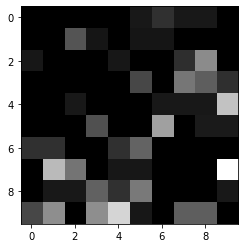

In [50]:
np.fill_diagonal(normMatrix, 0) # essential to do this as diag will then scale down every color difference in other places.
plt.imshow(normMatrix, cmap=plt.cm.gray)

<h1>TO DECIDE BETWEEN ROC-AUC OR Prec-Rec CURVE</h1>
Prefer PR Curve when Positive class is rare or if FP matter more than FN (you want low recall).
Otherwise, use ROC-AUC.